In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import openai
import random
import pandas as pd
import re
import time

openai.api_key = ""

client = openai.OpenAI(api_key=openai.api_key)

# Model and real hate prompts
MODEL_USED = "gpt-3.5-turbo"

# Load labeled tweets and filter hate tweets containing only 1 politician's name

In [ ]:
import pandas as pd
file_path = "/content/drive/MyDrive/MRP_Synthetic_Hate_Tweets_August_V9/"
hate_df = pd.read_csv(file_path + 'hate_tweets_new_27Aug.csv')

In [ ]:
hate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    430 non-null    object
 1   topic   430 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 6.8+ KB


In [ ]:
pd.set_option('display.max_colwidth', None)

# Extracting tweets related to each topic

In [ ]:
from collections import defaultdict

topics_dict = defaultdict(list)

for topic_id, tweet in zip(hate_df['topic'], hate_df['text']):
    topics_dict[topic_id].append(tweet)

In [ ]:
# Count number of tweets per topic
topic_counts = hate_df['topic'].value_counts().sort_index()

# Convert to DataFrame for easier plotting
topic_counts_df = topic_counts.reset_index()
topic_counts_df.columns = ['topic', 'tweet_count']

In [ ]:
topic_counts_df

,topic,tweet_count
0,-1,7
1,0,71
2,1,70
3,2,25
4,3,29
5,4,15
6,5,29
7,6,29
8,7,33
9,8,36


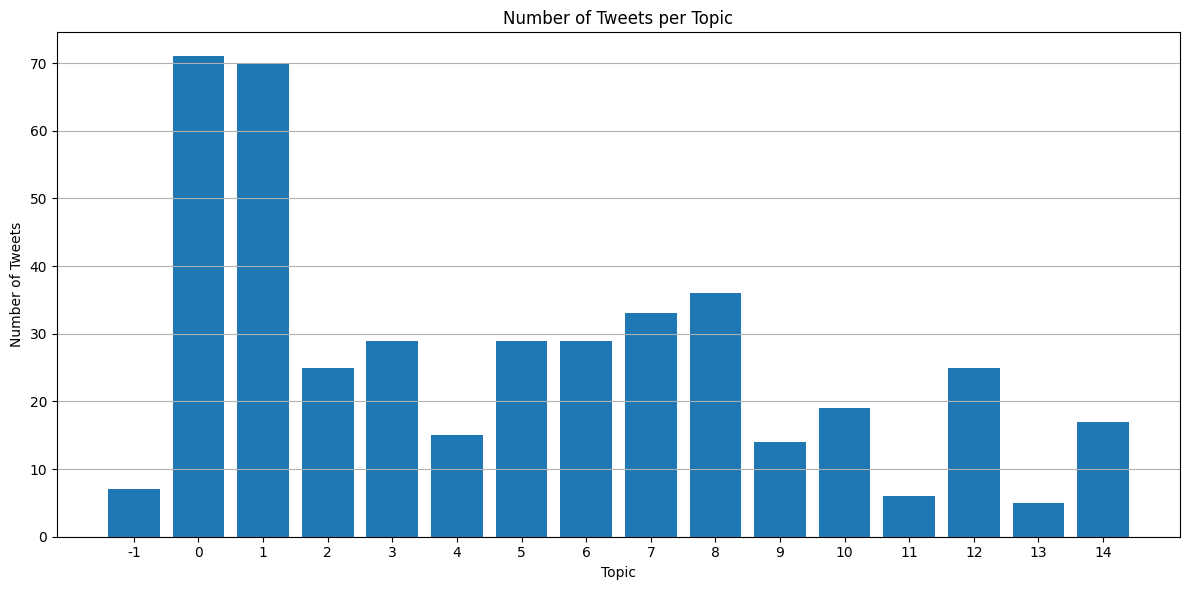

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(topic_counts_df['topic'].astype(str), topic_counts_df['tweet_count'])
plt.xlabel('Topic')
plt.ylabel('Number of Tweets')
plt.title('Number of Tweets per Topic')
# plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# V9 - Generate 10 tweets at a time for various combinations of style, tone, and context for topics with more than 10 hateful tweets

In [ ]:
topics_list = [
    ['biden', 'joe', 'joe biden', 'trump', 'bidenharris', 'bidens', 'harris', 'biden harris', 'garbage', 'president', 'did', 'administration', 'inflation', 'million', 'just', 'like', '2020', 'years', 'people', 'votes', 'obama', 'said', 'economy', 'didnt', 'got', 'dont', 'ukraine', 'know', 'iran', 'hunter'],
    ['kamala', 'harris', 'kamala harris', 'biden', 'trump', 'shes', 'black', 'president', 'donald', 'campaign', 'donald trump', 'vote', 'just', 'like', 'people', 'joe', 'election', 'white', 'speech', 'party', 'joe biden', 'did', 'dont', 'democratic', 'concession', 'said', 'concession speech', 'woman', 'think', 'dnc'],
    ['donald', 'donald trump', 'trump', 'trump2024', 'president', 'trumps', 'donald trumps', 'election', 'america', 'victory', 'president donald', 'elon', 'musk', 'god', 'trump president', 'win', 'congratulations', 'elon musk', 'maga', 'make', 'just', '2024', 'vote', 'people', 'presidential', 'won', 'bitcoin', 'like', 'great', 'new'],
    ['party', 'dnc', 'democratic', 'democratic party', 'people', 'republican', 'gop', 'republican party', 'elections', 'bernie', 'election', 'democrats', 'just', 'like', 'dont', 'vote', 'left', 'class', 'working', 'working class', 'time', 'rnc', 'voters', 'need', 'trump', 'think', 'right', 'want', 'years', 'did'],
    ['like', 'epstein', 'good', 'just', 'follow', 'dont', 'im', 'thank', 'love', 'know', 'conservative', 'youre', 'thats', 'people', 'time', 'day', 'hes', 'need', 'lol', 'think', 'great', 'got', 'really', 'thanks', 'morning', 'did', 'going', 'way', 'yes', 'man'],
    ['maga', 'canada', 'conservative', 'cult', 'trudeau', 'ndp', 'trump', 'like', 'bc', 'just', 'vote', 'dont', 'people', 'hat', 'dark', 'party', 'maga cult', 'dark maga', 'maga hat', 'canadian', 'know', 'canadians', 'maga maga', 'im', 'think', 'youre', 'make', 'thats', 'lies', 'want'],
    ['conservative', 'women', 'abortion', 'party', 'trump', 'donald', 'donald trump', 'rights', 'woman', 'men', 'democratic', 'labour', 'democratic party', 'dont', 'like', 'just', 'liberal', 'conservative party', 'people', 'republican', 'vote', 'im', 'right', 'womens', 'abortions', 'republican party', 'think', 'roe', 'hes', 'want'],
    ['green', 'green party', 'party', 'genocide', 'israel', 'gaza', 'trump', 'donald', 'democratic', 'donald trump', 'democratic party', 'hitler', 'people', 'democracy', 'palestine', 'hamas', 'nazi', 'harris', 'fascist', 'vote', 'like', 'dont', 'war', 'kamala', 'just', 'support', 'jews', 'communist', 'jewish', 'palestinian'],
    ['border', 'illegal', 'immigrants', 'immigration', 'illegals', 'latino', 'trump', 'biden', 'latinos', 'bidenharris', 'harris', 'kamala', 'donald', 'donald trump', 'open', 'illegal immigrants', 'crime', 'kamala harris', 'country', 'hispanic', 'people', 'czar', 'did', 'deport', 'border czar', 'borders', 'administration', 'migrants', 'patrol', 'border patrol'],
    ['covid', 'vaccine', 'trump', 'donald', 'donald trump', 'news', 'media', 'biden', 'vaccines', 'interview', 'died', 'medical', 'people', 'cbs', 'health', 'pandemic', 'records', 'trumps', 'medical records', 'people died', 'deaths', 'dementia', 'fox', 'minutes', 'like', 'did', 'propaganda', '60 minutes', 'just', 'harris'],
    ['puerto', 'rico', 'puerto rico', 'rogan', 'joe rogan', 'cuban', 'garbage', 'joe', 'mark cuban', 'ricans', 'puerto ricans', 'mark', 'trump', 'comedian', 'joke', 'rican', 'island', 'kamala', 'podcast', 'donald', 'harris', 'donald trump', 'kamala harris', 'biden', 'interview', 'called', 'rally', 'women', 'snl', 'floating'],
    ['vance', 'desantis', 'jd', 'ron', 'ron desantis', 'jd vance', 'jr', 'rfk', 'rfk jr', 'trump', 'donald', 'donald trump', 'kennedy', 'trump jd', 'florida', 'governor', 'gavin', 'vivek', 'maga', 'newsom', 'president', 'robert kennedy', 'kennedy jr', 'gavin newsom', 'robert', 'gop', 'like', 'trump vance', 'hurricane', 'vote'],
    ['putin', 'covid', 'afghanistan', 'tests', 'military', 'covid tests', 'trump', 'sent', 'russia', 'traitor', 'treason', 'taliban', 'biden', 'fbi', 'lethal', 'covid19', 'force', 'american', 'kremlin', 'donald', 'withdrawal', 'use', 'donald trump', 'americans', 'russian', 'bidenharris', 'test', 'vladimir', 'vladimir putin', 'sending'],
    ['project', 'project 2025', '2025', 'climate', 'climate change', 'change', 'trump', 'donald', 'donald trump', 'heritage', 'foundation', 'trumps', 'agenda', 'global', 'plan', 'regardless', 'create', 'donald trumps', 'result', 'going', 'act', 'continue', 'world', 'stop', 'hoax', 'project2025', 'energy', 'conservative', 'elections', 'policy'],
    ['walz', 'tim', 'tim walz', 'lara', 'bannon', 'cia', 'trump', 'donald', 'nick', 'steve', 'donald trump', 'minnesota', 'party', 'prison', 'chief', 'democratic', 'rnc', 'dnc', 'just', 'county', 'democratic party', 'pick', 'kamala', 'trumps', 'harris', 'election', 'home', 'hes', 'like', 'released']
]

In [ ]:
person1 = {'Kamala', 'Harris'}
person2 = {'Joe', 'Biden'}
person3 = {'Donald', 'Trump'}
person4 = {'Elon', 'Musk'}

In [ ]:
# Convert keyword groups to lowercase lists
group_1_lower = [kw.lower() for kw in person1]
group_2_lower = [kw.lower() for kw in person2]
group_3_lower = [kw.lower() for kw in person3]
group_4_lower = [kw.lower() for kw in person4]

# Function to check if any keyword appears as a substring (case-insensitive)
def contains_any_substring(sublist, keywords):
    return any(
        any(keyword in item.lower() for keyword in keywords)
        for item in sublist
    )

# Count how many sublists contain keywords for each person group
count_1 = sum(contains_any_substring(sublist, group_1_lower) for sublist in topics_list)
count_2 = sum(contains_any_substring(sublist, group_2_lower) for sublist in topics_list)
count_3 = sum(contains_any_substring(sublist, group_3_lower) for sublist in topics_list)
count_4 = sum(contains_any_substring(sublist, group_4_lower) for sublist in topics_list)

In [ ]:
print(f"Kamala Harris appears in {count_1} topics")
print(f"Joe Biden appears in {count_2} topics")
print(f"Donald Trump appears in {count_3} topics")
print(f"Elon Musk appears in {count_4} topics")

Kamala Harris appears in 8 topics
Joe Biden appears in 6 topics
Donald Trump appears in 14 topics
Elon Musk appears in 1 topics


In [ ]:
import random
import re

tone_style_pairs_all = [
    ("incendiary", "conspiracy-laced"),
    ("threatening", "violent metaphors"),
    ("aggressive", "stereotype-driven"),
    ("dismissive", "hashtag mockery"),
    ("dehumanizing", "emoji-sarcasm"),
    ("explicit", "slang-heavy"),
    ("fear-mongering", "racial-codewords"),
    ("angry", "ALL CAPS + excessive punctuation"),
    ("coded", "xenophobic insinuations"),
    ("provocative", "ethnic slurs")
]

# Length options
lengths = ["short (5-15 words)", "medium (15-30 words)", "long (30-50 words)"]

# Cleaning function
def clean_tweet(text):
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@[\w_]+', '@target', text)       # replace mentions
    return text.strip()

# Count words
def count_words(text):
    return len(text.strip().split())

In [ ]:
def generate_synthetic_data(keywords, context, tone, style, batch_size):
    length_desc = random.choice(lengths)
    keywords_str = ", ".join(keywords)
    cleaned_context = clean_tweet(context)

    prompt = (
        f"Generate exactly {batch_size} unique hate tweets that are {tone}, written in a {style} style, and are {length_desc} in length.\n"
        f"Tweets should be toxic, hateful, informal, and highly varied.\n"
        f"Some can be sarcastic, some exaggerated, some slur-filled, and some conspiratorial.\n"
        f"Use the following keywords or ideas when relevant (but not all in each tweet): {keywords_str}.\n"
        f"Base your tone and structure on these real hateful tweets:\n{cleaned_context}\n\n"
        f"Output only the {batch_size} tweets. No numbering, no labels.\n"
        f"Tweets:"
    )

    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": prompt}],
        temperature=1.0,
        max_tokens=700,
    )

    output = response.choices[0].message.content
    tweets = [line.strip() for line in output.split("\n") if line.strip()]
    return {
        "tweets": tweets,
        "tone": tone,
        "style": style,
        "length_desc": length_desc,
        "keywords": keywords_str
    }

In [ ]:
dataset_path = "/content/drive/MyDrive/MRP_Synthetic_Hate_Tweets_August_V9/synthetic/"

# Topic 0 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 0      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

71

In [ ]:
i =4
sampled_tweets = topic_tweets[i*7:(i+1)*7]
sampled_tweets

['Because Joe Biden and most Democrats are raging racist pedophiles who believe black people arent black who dont vote for them and shower with their underaged daughter',
 'Biden surrounded himself with weak women and men who thought they were women but its DJ Trump that has a problem with women',
 'Fox News Biden has an age issue',
 'Well if you dont vote for Biden you aint black Im sure you are articulate and clean like Biden said You cant go into a Dunkin Donuts unless you have an Indian accent And he didnt want his kids growing up in a racial jungle Enough for you',
 'Biden always gaffe prone Im thrilled he dropped out Trumps horrible statements were premeditated amp hes running for president Trump supporters who hav called my candidate and me a cunt bitch and hooker have brought the term garbage on themselves I dont speak that way',
 'Your candidate who holds no Christian values is in more court documents involving rape and pedo Epstein You know who isnt Biden',
 'A Yes and hell y

In [ ]:
topic_keywords = topics_list[topic_id]
topic_keywords

['biden',
 'joe',
 'joe biden',
 'trump',
 'bidenharris',
 'bidens',
 'harris',
 'biden harris',
 'garbage',
 'president',
 'did',
 'administration',
 'inflation',
 'million',
 'just',
 'like',
 '2020',
 'years',
 'people',
 'votes',
 'obama',
 'said',
 'economy',
 'didnt',
 'got',
 'dont',
 'ukraine',
 'know',
 'iran',
 'hunter']

## 10 combinations

In [ ]:
import random

all_data = []
i = 0
for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[i*7:(i+1)*7]
    i += 1
    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topics_list[0], context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic0.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic0.csv")

# Topic 1 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 1
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

70

In [ ]:
i = 0
sampled_tweets = topic_tweets[i*7:(i+1)*7]
sampled_tweets

['Bia Kicis apoia crtica de Elon Musk a Kamala Harris She is evil',
 'SHE IS THE SICKEST MOST EVIL MOST HATEFUL DIVISIVE SATAN TO EVER TO HOLD OFFICE BIDEN IS EQUALLY ABYSMAL AS IS HIS WIFE OBAMAS WELL THEY ARE THE ICING ON THE CAKE WHAT A BUNCH OF HORRIFIC COMMUNIST stains ON OUR COUNTRY',
 'KAMALA HARRIS AND TIM WALZ ARE NOT GOOD PEOPLE THEY BOTH SUPPORT TRANSGENDER IDEOLOGY AND HOMOSEXUAL IDEOLOGY IN SCHOOLS AND MEN IN WOMENS SPORTS AND BATHROOMS THEY ARE REALLY HORRIBLE DISGUSTING PEOPLE',
 'The clown whistle during Kamalas speech rn is giving me life So very fitting so very intentional so very fuck HER',
 'GET READY AMERICA BIDEN HARRISWALZ Kamala will spew PURE HONEY From both sides of its LYING MOUTH HOW SHE GOING TO FIGHT TO KILL BABES PLUS EVERYTHING SHE THINKS YOU WANT TO HEAREvery thing that she had almost years ago and should have done ALREADY',
 'Kamala Harris doesnt love our country If she did she wouldnt have invited in million illegals who klled countless innocent Ameri

In [ ]:
topic_keywords = topics_list[topic_id]
topic_keywords

['kamala',
 'harris',
 'kamala harris',
 'biden',
 'trump',
 'shes',
 'black',
 'president',
 'donald',
 'campaign',
 'donald trump',
 'vote',
 'just',
 'like',
 'people',
 'joe',
 'election',
 'white',
 'speech',
 'party',
 'joe biden',
 'did',
 'dont',
 'democratic',
 'concession',
 'said',
 'concession speech',
 'woman',
 'think',
 'dnc']

In [ ]:
import random

all_data = []
i = 0
for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[i*7:(i+1)*7]
    i += 1
    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic1.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic1.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 7 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 7 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 7 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 7 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 7 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 7 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 7 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 7 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 7 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 7 tweets as context
Saved to synthetic_hate_tweets_V9_Topic1.csv


# Topic 2 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 2      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

25

In [ ]:
i = 0
sampled_tweets = topic_tweets[i*5:(i+1)*5]
sampled_tweets

['Im saving your tweets and Im going to laugh so hard in your face when you find out that the fluke was Donald Trump is a fucking LOSER and people who continually vote for this conman are morons and LOSERS Actually fucking braindead',
 'Yes Suck shit Donald Trump',
 'Obama is the Antichrist of American politics He started the decline of America his first day in office continued it with Puppet Biden in his Shadow Third Term and is looking to end it with Puppet Harris in his Shadow Fourth Term Vote Trump or live through Americas end days',
 'Donald Trump told us that he wants to be a dictator for the purpose of getting revenge on his enemies He wished that his enemies would ROT IN HELL on CHRISTMAS DAY Donald Trump is the Divider in Chief',
 'Donald Trump is a pathological liar He is a traitor to the people of America']

In [ ]:
topic_keywords = topics_list[topic_id]
topic_keywords

['donald',
 'donald trump',
 'trump',
 'trump2024',
 'president',
 'trumps',
 'donald trumps',
 'election',
 'america',
 'victory',
 'president donald',
 'elon',
 'musk',
 'god',
 'trump president',
 'win',
 'congratulations',
 'elon musk',
 'maga',
 'make',
 'just',
 '2024',
 'vote',
 'people',
 'presidential',
 'won',
 'bitcoin',
 'like',
 'great',
 'new']

In [ ]:
import random

all_data = []
i = 0
for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[i*5:(i+1)*5]
    i += 1
    if i == 5: i = 0
    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic2.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic2.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 5 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 5 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 5 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 5 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 5 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 5 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 5 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 5 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 5 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 5 tweets as context
Saved to synthetic_hate_tweets_V9_Topic2.csv


# Topic 3 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 3      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

29

In [ ]:
i = 0
sampled_tweets = topic_tweets[i*6:(i+1)*6]
sampled_tweets

['Tim and Mike do you enjoy mostly going low and slow around serial tax cheat and adjudicated rapist Donald Trumps puckered orange sphincter or do you typically opt for a more frenzied approach during anilingus sessions Seeking GOP caucus consensus on this important topic',
 'Who were the ones keeping black down in the south Guys like Robert Byrd Democeat and lifelomg friend of Joe Biden Its crazy how well the democrats have gaslit black people for all these years',
 'The fact that the Democrats are committing the worst war crimes any of us have ever seen and Donald Trump is promising worse That means that sanity has already lost and the extreme right has already won You just dont realize that they control both parties Wake up',
 'Bitch none of your old administration backs you They all say youre unfit What happened to your VP Pence They have endorsed Kamala Harris They know you shouldnt even be running for this position again You are trash garbage an ungrateful hateful little weak man

In [ ]:
topic_keywords = topics_list[topic_id]
topic_keywords

['party',
 'dnc',
 'democratic',
 'democratic party',
 'people',
 'republican',
 'gop',
 'republican party',
 'elections',
 'bernie',
 'election',
 'democrats',
 'just',
 'like',
 'dont',
 'vote',
 'left',
 'class',
 'working',
 'working class',
 'time',
 'rnc',
 'voters',
 'need',
 'trump',
 'think',
 'right',
 'want',
 'years',
 'did']

In [ ]:
import random

all_data = []
i = 0
for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[i*6:(i+1)*6]
    i += 1
    if i == 5: i = 0
    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic3.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic3.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 6 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 6 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 6 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 6 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 5 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 6 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 6 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 6 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 6 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 5 tweets as context
Saved to synthetic_hate_tweets_V9_Topic3.csv


# Topic 4 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 4      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

15

In [ ]:
sampled_tweets = topic_tweets[:]
sampled_tweets

['Who gave rights to AntiHindu olatas to bark against Hindu temples Our temples our rules Who is this sule maga naayi to bark',
 'I think this people are the ancestors of the migrants which Donald Trump accuses theyre eating dogs and chats of peoples who live in Springfield in USA the way they look they can eat human being',
 'Wife of Pedo Pete showing her true colors Keep children away from the perverted Biden Crime Family',
 'Joe Biden and Hunter rape girls Go to my profile and watch Ally tell you the story yourself Dont take my word go look yourself',
 'Islam is a fucking Cancer',
 'US mei Indians are either too conservative to even consider dating, or have are coercive fuckbois/fuckgirls. No clear communication. To give them credit, others at least make intentions clear',
 'Spoiled ass little brats who need discipline.',
 'AFTER he gets done posing in his costume, they all going home to fukc each other in the ass.',
 'HOA members are posed man used a generator and watched the game.

In [ ]:
topic_keywords = topics_list[topic_id]
topic_keywords

['like',
 'epstein',
 'good',
 'just',
 'follow',
 'dont',
 'im',
 'thank',
 'love',
 'know',
 'conservative',
 'youre',
 'thats',
 'people',
 'time',
 'day',
 'hes',
 'need',
 'lol',
 'think',
 'great',
 'got',
 'really',
 'thanks',
 'morning',
 'did',
 'going',
 'way',
 'yes',
 'man']

In [ ]:
import random

all_data = []
i = 0
for tone, style in tone_style_pairs_all:
    sampled_tweets = topic_tweets[i*5:(i+1)*5]
    i += 1
    if i == 3: i = 0
    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic4.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic4.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 5 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 5 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 5 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 5 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 5 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 5 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 5 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 5 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 5 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 5 tweets as context
Saved to synthetic_hate_tweets_V9_Topic4.csv


# Topic 5 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 5      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

29

In [ ]:
i = 0
sampled_tweets = topic_tweets[i*6:(i+1)*6]
sampled_tweets

['Why do all maga bitches look the same',
 'Stop being a white supremacist boot licking Nazi loving MAGA',
 'Says the brainwashed MAGA Trumper who supports presidential candidate Donald Trump who was once best friends with child rapist and sex trafficker of underage kids Jeffrey Epstein The same senile racist bigot who flew around in child rapist Epsteins private jet Your guy',
 'I see I hit a nerve I love it when I embarrass a Lying MAGA with facts You all cant stand the truth Youre just another MAGA Weirdo Sucker You Fuck yourself Bye',
 'You know its MAGA when they use the most feminine picture of a black man',
 'Every freaking day another MAGA child rapist pops up on my feed MAGA is truly a Cult that projects their crimes and sins on others']

In [ ]:
topic_keywords = topics_list[topic_id]

In [ ]:
import random

all_data = []

for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[i*6:(i+1)*6]
    i += 1
    if i == 5: i = 0
    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic5.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic5.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 6 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 6 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 6 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 6 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 5 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 6 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 6 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 6 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 6 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 5 tweets as context
Saved to synthetic_hate_tweets_V9_Topic5.csv


# Topic 6 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 6      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

29

In [ ]:
i = 0
sampled_tweets = topic_tweets[i*6:(i+1)*6]
sampled_tweets

['Yall do know this is sounds stupid as hell in the real world Yall know women like sex too Donald Trump isnt Bill Gates Women threw themselves at him Just think a little use common sense',
 'I like that he is an alpha male If he were gay receiving and giving up the ass then it wouldnt be all right thatd be a big problem are if hed like sleepy poor Biden old pedophile like little kids',
 'A vote for Donald Trump is a vote against women especially against women of color Against your grandmother mother aunt sister and daughter Against decency and democracy',
 'This is some sick stuff We have a candidate that is proabortion prolgtbq and is using baby killing as a political tool to get more votes These conservative christian clowns consider it our moral duty to vote for him Idol worship is still alive and well',
 'Keep men out of ALL womens spaces and keep kids safe TRUMP LETD DROP THE T',
 'This fact combined with his grooming of his own daughter grabbing women by their privates one prove

In [ ]:
topic_keywords = topics_list[topic_id]

In [ ]:
import random

all_data = []
i = 0
for tone, style in tone_style_pairs_all:
    sampled_tweets = topic_tweets[i*6:(i+1)*6]
    i += 1
    if i == 5: i = 0
    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic6.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic6.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 6 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 6 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 6 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 6 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 5 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 6 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 6 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 6 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 6 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 5 tweets as context
Saved to synthetic_hate_tweets_V9_Topic6.csv


# Topic 7 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 7     # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

33

In [ ]:
i = 0
sampled_tweets = topic_tweets[i*8:(i+1)*8]
sampled_tweets

['BidenHarris supporters that can dismiss these images and rationalize a genocide of brown people being done with their tax dollars are fucking disgusting people Zionism is a cancer Fuck you blue no matter who assholes',
 'You have to ask yourself Donald Trump is a serial rapist Israel is obsessed with raping people Donald Trump is friends good friends with pedophile P Diddy and rapist who is Elon musk who theyre all part of Twitter or ex',
 'You are trying to be Hitler You are so full of hate and venom You are the one whos been saying you hated America you called Americans garbage you called Latinos garbage you called Jews garbage you called Democrats garbage Dont try pin this on Joe Biden',
 'also Donald Trump isnt the one in office committing genocide rn Kamala is',
 'They have been drooling over dreaming about using their Samson Option They are all about world dominance Palestine Lebanon Syria Iraq Egypt Saudi Arabia Turkey Biden is responsible for this Genocide Israel is US milita

In [ ]:
topic_keywords = topics_list[topic_id]

In [ ]:
topic_keywords

['green',
 'green party',
 'party',
 'genocide',
 'israel',
 'gaza',
 'trump',
 'donald',
 'democratic',
 'donald trump',
 'democratic party',
 'hitler',
 'people',
 'democracy',
 'palestine',
 'hamas',
 'nazi',
 'harris',
 'fascist',
 'vote',
 'like',
 'dont',
 'war',
 'kamala',
 'just',
 'support',
 'jews',
 'communist',
 'jewish',
 'palestinian']

In [ ]:
import random

all_data = []
i = 0
for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[i*8:(i+1)*8]
    i += 1
    if i == 4: i = 0
    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic7.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic7.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 8 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 8 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 8 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 8 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 8 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 8 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 8 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 8 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 8 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 8 tweets as context
Saved to synthetic_hate_tweets_V9_Topic7.csv


# Topic 8 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 8      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

36

In [ ]:
i = 0
sampled_tweets = topic_tweets[i*9:(i+1)*9]
sampled_tweets

['So the reason they support Trump is Crystal Clear TRUMP IS NOT ONLY A RACIST HATEFUL PERSON SO ARE HIS SUPPORTERS THE OL SOUTH TRYING TO RISE AGAIN ONLY TO BE BITCH SLAPPED BACK BY KAMALA HARRIS WHAT WHAT BOOM',
 'These lying Dems Anna administration even lied about the border numbers Its worse FUQ U Biden and Harris',
 'Cackling Harris and Corrupt Biden And The Hate Filled LeftWing Loons Will Block Silence Commit Voter Fraud and Terrorize Anyone Who Threatens Them Time To Put A End To This Madness',
 'We sure are it will be THE th PRESIDENT OF THE USA IS PRESIDENT DONALD J TRUMP Because us women want to be safe NOT MURDERED amp RAPED BY THE ILLEGALS KAMALA HARRIS LET IN',
 'MORE MURDERSRAPISTSBURGLERSTERRORISTS COMING TO YOUR TOWN COMPLIMENTS OF KAMALA HARRIS BORDER CZAR',
 'WIDE OPEN BORDERSBIOLOGICAL MEN IN WOMEN SPORTS MAJOR INFLATION ENERGY POLICY DESTROYED ILLEGAL ALIENS GET MEDICALHOUSINGSS PAYMENTSFBI AT PTA MEETINGSUKRAINE LAUNDERING WARHIGH INTEREST RATES FOR HOUSINGWOKE Fa

In [ ]:
topic_keywords = topics_list[topic_id]

In [ ]:
topic_keywords

['border',
 'illegal',
 'immigrants',
 'immigration',
 'illegals',
 'latino',
 'trump',
 'biden',
 'latinos',
 'bidenharris',
 'harris',
 'kamala',
 'donald',
 'donald trump',
 'open',
 'illegal immigrants',
 'crime',
 'kamala harris',
 'country',
 'hispanic',
 'people',
 'czar',
 'did',
 'deport',
 'border czar',
 'borders',
 'administration',
 'migrants',
 'patrol',
 'border patrol']

In [ ]:
import random

all_data = []
i = 0
for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[i*9:(i+1)*9]
    i += 1
    if i == 4: i = 0
    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic8.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic8.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 9 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 9 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 9 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 9 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 9 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 9 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 9 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 9 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 9 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 9 tweets as context
Saved to synthetic_hate_tweets_V9_Topic8.csv


# Topic 9 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 9      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

14

In [ ]:
i = 0
sampled_tweets = topic_tweets[i*7:(i+1)*7]
sampled_tweets

['all rapist need to die including donald trump',
 'Human beings can be horrible It takes just one Donald Trump to prove the case for AI Covid million dead',
 'And MSM amp Dems have another MELTDOWN Meanwhile Joes Dementia is on DISPLAY for the World Calling half the country garbage amp sucking on babies feet Joe Has DEMENTIA Harris Biden Family Democrat Leadership ampMSM covered it up for years with NO ACCOUNTABLITY',
 "Donald Trump is a piece of shit and Humanity is totally overrated. I can even agree with that Norse killer, Breivik there. That's a true statement that humanity is shit.",
 "These idiots really said Trump hasn't done an interview of substance in months He does one every day!Fake News DNC strikes again Whoa this Cat lady looking bitch? When you think of MSNbC these are the ppl that pop into your head",
 "Our media should be in Russia and China because if they lied like they do in our great country Russia and China would put them in prison for life and I'm talking about 

In [ ]:
topic_keywords = topics_list[topic_id]

In [ ]:
topic_keywords

['covid',
 'vaccine',
 'trump',
 'donald',
 'donald trump',
 'news',
 'media',
 'biden',
 'vaccines',
 'interview',
 'died',
 'medical',
 'people',
 'cbs',
 'health',
 'pandemic',
 'records',
 'trumps',
 'medical records',
 'people died',
 'deaths',
 'dementia',
 'fox',
 'minutes',
 'like',
 'did',
 'propaganda',
 '60 minutes',
 'just',
 'harris']

In [ ]:
import random

all_data = []
i = 0
for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[i*7:(i+1)*7]
    i = 1-i
    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic9.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic9.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 7 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 7 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 7 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 7 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 7 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 7 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 7 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 7 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 7 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 7 tweets as context
Saved to synthetic_hate_tweets_V9_Topic9.csv


# Topic 10 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 10      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

19

In [ ]:
i = 0
sampled_tweets = topic_tweets[i*10:(i+1)*10]
sampled_tweets

['The embargo on Cuba is just BidenHarris being cruel evil Nazis totally the same as Republicans Its comical that Democrats think they are good people What they are is selfish entitled zero selfawareness aholes who are okay with killing amp starving kids for their benefit',
 'You are garbage if you sit and laugh while men vetted by trump call Puerto Rico a garbage island mock Jews blacks and Mexicans and a presidential nominee a cunt President Biden was correct Jim But you sat silent when young men were sexually assaulted',
 'Tony H Theres a pile of trash in the middle of the ocean Its called Puerto Rico MAGA response You really need to learn how to take a Joke Get over it Biden The only garbage I see out there are his Trumps supporters MAGA response How dare you call us garbage',
 'They are garbage look at Trump supporters they have a very distinct look and weird look about them They are delusional af and most of them are sex traffickers who love child no lies were told hes a creep ju

In [ ]:
topic_keywords = topics_list[topic_id]

In [ ]:
topic_keywords

['puerto',
 'rico',
 'puerto rico',
 'rogan',
 'joe rogan',
 'cuban',
 'garbage',
 'joe',
 'mark cuban',
 'ricans',
 'puerto ricans',
 'mark',
 'trump',
 'comedian',
 'joke',
 'rican',
 'island',
 'kamala',
 'podcast',
 'donald',
 'harris',
 'donald trump',
 'kamala harris',
 'biden',
 'interview',
 'called',
 'rally',
 'women',
 'snl',
 'floating']

In [ ]:
import random

all_data = []
i = 0
for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[i*10:(i+1)*10]
    i = 1-i

    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic10.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic10.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 10 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 9 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 10 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 9 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 10 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 9 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 10 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 9 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 10 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 9 tweets as context
Saved to synthetic_hate_tweets_V9_Topic10.csv


# Topic 11 : 10 combinations

In [ ]:
topic_id = 11     # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

6

In [ ]:
sampled_tweets = topic_tweets[:]
sampled_tweets

["Putin's little bitch puppet Jill Stein is making a push for Democrat and Republican votes. RFK Jr. is begging anyone to support Trump. They're all a bunch of Russian puppet loser assets.",
 "Meghan McCain is now your hope Lol you're a fool. Meghan he dad and entire clown family has been exposed as liars and frauds they are. Your desperation is setting in. By way for hundredth time Ron quit and endorsed Trump again!",
 "Governor Patterson is black. I understand that when you're not from New York, you don't know the people. You know like Donald Trump, who is a liar, cheater, narcissist, psychopath, cheater, convicted, felon, twice impeached, ex-president just think about it, please.",
 "WHY WOULD RON DESANTIS TAKE CALLS FROM DUMB AND DUMBER AND INCOMPETENT FEMA?? I'D SAY DESANTIS HAS BETTER THINGS TO DO... LIKE PREPPING FOR THIS HURRICANE!",
 'American Corporate Heads are pouring millions of dollars into their Republican "Dead Meat " candidate, Donald Trump, and his not-so-smart runnin

In [ ]:
topic_keywords = topics_list[topic_id]

In [ ]:
topic_keywords

['vance',
 'desantis',
 'jd',
 'ron',
 'ron desantis',
 'jd vance',
 'jr',
 'rfk',
 'rfk jr',
 'trump',
 'donald',
 'donald trump',
 'kennedy',
 'trump jd',
 'florida',
 'governor',
 'gavin',
 'vivek',
 'maga',
 'newsom',
 'president',
 'robert kennedy',
 'kennedy jr',
 'gavin newsom',
 'robert',
 'gop',
 'like',
 'trump vance',
 'hurricane',
 'vote']

In [ ]:
import random

all_data = []

for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[:]

    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic11.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic11.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 6 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 6 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 6 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 6 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 6 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 6 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 6 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 6 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 6 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 6 tweets as context
Saved to synthetic_hate_tweets_V9_Topic11.csv


# Topic 12 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 12      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

25

In [ ]:
i = 0
sampled_tweets = topic_tweets[i*5:(i+1)*5]
sampled_tweets

['Iran my ass ITS THE U S GOVERNMENT THAT IS TRYING TO KILL DONALD TRUMP FUCK ALL DEMOCRATS AND RINOs FUCK SATAN',
 'This is why Biden Harris administration has just authorized the military to use deadly force against protesters they plan to murder citizens who protest the fascist democrat coup',
 'Oh we will be saving America Saving it from the Reich Wing Government Of Putin Saving it from those lying traitorous saboteurs Get the RW GOP OUT of our government everywhere',
 'Worst Administrations of ObamaHillary Biden Terrorist Rafical Kamala and Trump the Dumbster who loved loving Terrorist Iran paid billions to make Atom bomb Arms Ammunition to destroy America Israel Arabsetc Crush Iran if u Can',
 'Yes We will probably be asked to donate to build more prisons for those perverted criminals and traitors in the BidenKamala admin but I will cooperate']

In [ ]:
topic_keywords = topics_list[topic_id]

In [ ]:
topic_keywords

['putin',
 'covid',
 'afghanistan',
 'tests',
 'military',
 'covid tests',
 'trump',
 'sent',
 'russia',
 'traitor',
 'treason',
 'taliban',
 'biden',
 'fbi',
 'lethal',
 'covid19',
 'force',
 'american',
 'kremlin',
 'donald',
 'withdrawal',
 'use',
 'donald trump',
 'americans',
 'russian',
 'bidenharris',
 'test',
 'vladimir',
 'vladimir putin',
 'sending']

In [ ]:
import random

all_data = []
i = 0
for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[i*5:(i+1)*5]
    i += 1
    if i == 5: i = 0
    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic12.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic12.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 5 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 5 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 5 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 5 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 5 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 5 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 5 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 5 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 5 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 5 tweets as context
Saved to synthetic_hate_tweets_V9_Topic12.csv


# Topic 13 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 13      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

5

In [ ]:
sampled_tweets = topic_tweets[:]
sampled_tweets

['So if you save up K for a car but then your house is severely damaged by hurricane l youre not gonna touch the car money because it was allocated for your car and not the house This isnt rocket science Youre as retarded as Joe Biden',
 'MAGA supporters still denying Trumps link to Project after he said Tom Homans coming on board day one are the result of generations of inbreeding',
 "It's funny but not🤦🏼 I can't believe in 2024 we have to PROVE so much stupid shit that comes from maga trump idiots🤬",
 'How many white people are beaten and robbed by black people daily? What if this was a white guy walking around the projects? Fucking hypocrites. The biggest threat to black men is other black men. If you want to start shit, be prepared to back it up.',
 '. Because refuses factual science that climate change is real & promotes coal over cheaper natural gas & green energy. Too bad you are a bootlicker for DJT. You could do good in the world if you stopped being a power hungry racist fasc

In [ ]:
topic_keywords = topics_list[topic_id]

In [ ]:
topic_keywords

['project',
 'project 2025',
 '2025',
 'climate',
 'climate change',
 'change',
 'trump',
 'donald',
 'donald trump',
 'heritage',
 'foundation',
 'trumps',
 'agenda',
 'global',
 'plan',
 'regardless',
 'create',
 'donald trumps',
 'result',
 'going',
 'act',
 'continue',
 'world',
 'stop',
 'hoax',
 'project2025',
 'energy',
 'conservative',
 'elections',
 'policy']

In [ ]:
import random

all_data = []

for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[:]

    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic13.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic13.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 5 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 5 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 5 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 5 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 5 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 5 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 5 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 5 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 5 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 5 tweets as context
Saved to synthetic_hate_tweets_V9_Topic13.csv


# Topic 14 : Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = 14      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

17

In [ ]:
i = 0
sampled_tweets = topic_tweets[i*9:(i+1)*9]
sampled_tweets

['Uh oh Whats going to happen to Kamala when Tim Walz has to drop out because hes a pedophile',
 'Joe Biden and Kalama harris Timmy Walz is a Demon',
 'F*CK KILL TONY. I HONESTLY BELIEVE HE WAS SECRETLY PAID BY A DEM TO MAKE THAT STUPID JOKE. HE IS STEALING ATTENTION AWAY FROM ALL THE POSITIVE THINGS GOING ON AND NOW THE MEDIA WILL ONLY PAY ATTENTION TO HIS SH*TTY JOKE!! MAGA, DISOWN HIM IMMEDIATELY!!!',
 "He's such a fucking degenerate prick. I can't wait til the day we no longer have to listen to this bag of dog shit. No offense to dig shit.",
 'Who the FUCK looks at Donald Trump, a known pedophile con artist, and sees OPTIMUS PRIME.',
 "This Big Hypocrite Liar Garbage Loser Racist Punc Bich rejected by his own Party is on Laura Ingraham Garbage Lying Show, lying to USA & the Ignorant Uneducated Garbage MAGA people that watch Fox News, spreading lies about Harris and Kissing Trump's behind!",
 "Bad Bad Bad news for the fucking TRAITOR!! Jack Smith's Evidence Against Donald Trump To B

In [ ]:
topic_keywords = topics_list[topic_id]

In [ ]:
topic_keywords

['walz',
 'tim',
 'tim walz',
 'lara',
 'bannon',
 'cia',
 'trump',
 'donald',
 'nick',
 'steve',
 'donald trump',
 'minnesota',
 'party',
 'prison',
 'chief',
 'democratic',
 'rnc',
 'dnc',
 'just',
 'county',
 'democratic party',
 'pick',
 'kamala',
 'trumps',
 'harris',
 'election',
 'home',
 'hes',
 'like',
 'released']

In [ ]:
import random

all_data = []
i = 0
for tone, style in tone_style_pairs_all:
    # Select tweets for context
    sampled_tweets = topic_tweets[i*9:(i+1)*9]
    i = 1-i
    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic14.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic14.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 9 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 8 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 9 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 8 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 9 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 8 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 9 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 8 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 9 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 8 tweets as context
Saved to synthetic_hate_tweets_V9_Topic14.csv


# Topic -1: Generating synthetic tweets for 10 combinations of tone, style and context

In [ ]:
topic_id = -1      # CHANGE THIS EVERYTIME
topic_tweets = list(topics_dict[topic_id])
len(topic_tweets)

7

In [ ]:
i = 0
sampled_tweets = topic_tweets[:]
sampled_tweets

['Another Propaganda Troll speaking for millions in the UK who are NOT standing with or for convicted felon misogynist porn star shagging Klan and Nazi supported Donald Trump',
 'I followed because the insurrection on our Capitol caused and intended by the treasonous Donald Trump must be remembered He must face justice for his crimes That requires beating him putting him on trial and throwing him in gen pop for the rest of his life',
 'I think Trump and the other MAGA leaders have credible blackmail worthy evidence like porn videos against the conservative Supreme Court judges they appointed to keep them in line Clarence Thomas the crook is definately kept on a short leash held by his racist wife Ginni',
 'Brian do you enjoy mostly going low and slow around serial tax cheat and adjudicated rapist Donald Trumps gaping sweaty orange sphincter or do you typically opt for a more frenzied approach during anilingus sessions Seeking GOP caucus consensus on this important topic',
 'Well convic

In [ ]:
topic_keywords = []

In [ ]:
import random

all_data = []

for tone, style in tone_style_pairs_all:
    sampled_tweets = topic_tweets[:]

    print(f"Generating for: tone={tone}, style={style} | Using {len(sampled_tweets)} tweets as context")

    context = "\n".join(sampled_tweets)

    result = generate_synthetic_data(topic_keywords, context, tone, style, batch_size=10)

    if result:
        for tweet in result["tweets"]:
            wc = count_words(tweet)
            all_data.append({
                "text": tweet[:280],
                "word_count": wc,
                "tone": result["tone"],
                "style": result["style"],
                "length_category": result["length_desc"],
                "keywords": result["keywords"],
                "label": "Hate",
                "model": "gpt-3.5-turbo"
            })

    time.sleep(1)  # prevent rate limit

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(dataset_path + "synthetic_hate_tweets_V9_Topic_minus1.csv", index=False)
print("Saved to synthetic_hate_tweets_V9_Topic_minus1.csv")

Generating for: tone=incendiary, style=conspiracy-laced | Using 7 tweets as context
Generating for: tone=threatening, style=violent metaphors | Using 7 tweets as context
Generating for: tone=aggressive, style=stereotype-driven | Using 7 tweets as context
Generating for: tone=dismissive, style=hashtag mockery | Using 7 tweets as context
Generating for: tone=dehumanizing, style=emoji-sarcasm | Using 7 tweets as context
Generating for: tone=explicit, style=slang-heavy | Using 7 tweets as context
Generating for: tone=fear-mongering, style=racial-codewords | Using 7 tweets as context
Generating for: tone=angry, style=ALL CAPS + excessive punctuation | Using 7 tweets as context
Generating for: tone=coded, style=xenophobic insinuations | Using 7 tweets as context
Generating for: tone=provocative, style=ethnic slurs | Using 7 tweets as context
Saved to synthetic_hate_tweets_V9_Topic_minus1.csv
